# **Project Name**   - DeepCSAT – E-commerce Customer Satisfaction Score Prediction



##### **Project Type**    - Deep learning
##### **Contribution**    - Individual
##### **Team Member 1 -** PREDEEP KUMAR
##### **Team Member 2 -** N.A
##### **Team Member 3 -** N.A
##### **Team Member 4 -** N.A

# **Project Summary -**

The DeepCSAT project focuses on building an end-to-end machine learning system to predict Customer Satisfaction (CSAT) scores using customer support interaction data. The project begins with comprehensive data preprocessing, including cleaning, feature engineering, and natural language processing (NLP) of customer remarks to extract meaningful information from text data.

Exploratory Data Analysis (EDA) and statistical hypothesis testing were conducted to understand the relationships between key variables such as response time, communication channel, and issue category with customer satisfaction. These insights helped identify factors that significantly influence CSAT.

Multiple deep learning architectures were developed, including Baseline ANN, Deep ANN, and Dropout ANN, and their performance was compared using evaluation metrics such as accuracy, precision, recall, F1-score, and confusion matrix. Hyperparameter tuning was applied to improve model performance and select the most stable configuration.

Finally, the trained model was integrated into an interactive Streamlit dashboard that allows real-time CSAT prediction and visualization of insights. The project demonstrates a complete machine learning workflow from data preparation to model deployment, highlighting practical machine learning engineering practices for customer experience analytics.

# **GitHub Link -**

https://github.com/Predeep-Kumar/DeepCSAT.git

# **Problem Statement**


The primary objective of this project is to develop a deep learning–based predictive system capable of accurately estimating Customer Satisfaction (CSAT) scores using customer support interaction data and feedback. By leveraging structured features such as response time, communication channel, issue category, and customer remarks, the system aims to identify patterns that influence customer satisfaction.

This solution enables e-commerce and customer support teams to predict customer satisfaction levels proactively, allowing businesses to monitor service performance, identify potential dissatisfaction early, and implement timely improvements. Ultimately, the goal is to enhance overall service quality, improve customer experience, and strengthen long-term customer loyalty through data-driven insights.

# ***Let's Begin !***

## **1. Importing Libraries**

### Import Basic Libraries

In [ ]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import joblib
import seaborn as sns

warnings.filterwarnings("ignore")

# Visualization settings
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

print("Basic libraries loaded successfully")

Basic libraries loaded successfully


### Machine Learning Libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

print("ML libraries loaded")

ML libraries loaded


### Deep Learning Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## **2. Environment Setup**

ENVIRONMENT DETECTION

In [ ]:
if "google.colab" in sys.modules:
    ENVIRONMENT = "COLAB"
else:
    ENVIRONMENT = "LOCAL"

print(f"Running in {ENVIRONMENT} environment")

Running in COLAB environment


Mount Google Drive

In [ ]:
if ENVIRONMENT == "COLAB":
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Path Configuration

In [ ]:
if ENVIRONMENT == "COLAB":
    BASE_PATH = "/content/drive/MyDrive/DeepCSAT"
else:
    BASE_PATH = os.getcwd()

DATA_PATH = os.path.join(BASE_PATH, "data")
RAW_DATA_PATH = os.path.join(DATA_PATH, "raw")
PROCESSED_DATA_PATH = os.path.join(DATA_PATH, "processed")

OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")
PLOT_PATH = os.path.join(OUTPUT_PATH, "plots")
MODEL_PATH = os.path.join(BASE_PATH, "models")
TUNING_PATH = os.path.join(MODEL_PATH, "tuning")

print("Base Path:", BASE_PATH)

Base Path: /content/drive/MyDrive/DeepCSAT


Create Project Directories

In [ ]:
os.makedirs(RAW_DATA_PATH, exist_ok=True)
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)
os.makedirs(PLOT_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(TUNING_PATH, exist_ok=True)

print("Project directories created successfully")

Project directories created successfully


Verify File Location

In [ ]:
print("Files in data directory:")
print(os.listdir(RAW_DATA_PATH))

Files in data directory:
['eCommerce_Customer_support_data.csv']


## **3. Data Loading & Data Understanding**

Import Data Handling Utilities

In [ ]:
import pandas as pd
import numpy as np

print("Data utilities ready")

Data utilities ready


Detect Dataset File

In [ ]:
files = os.listdir(RAW_DATA_PATH)

print("Files found in raw data directory:")
for f in files:
    print(" -", f)

Files found in raw data directory:
 - eCommerce_Customer_support_data.csv


Define Dataset Path

In [ ]:
DATA_FILE = None

for file in os.listdir(RAW_DATA_PATH):
    if file.endswith(".csv"):
        DATA_FILE = os.path.join(RAW_DATA_PATH, file)
        break

if DATA_FILE is None:
    raise FileNotFoundError("No CSV dataset found in raw data folder")

print("Dataset found at:", DATA_FILE)

Dataset found at: /content/drive/MyDrive/DeepCSAT/data/raw/eCommerce_Customer_support_data.csv


Load Dataset

In [ ]:
df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully")

Dataset loaded successfully


Dataset First View

In [ ]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


Dataset Rows & Columns count

In [ ]:

rows, cols = df.shape

print(f"Dataset Shape : {df.shape}")
print("----------------------")
print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Dataset Shape : (85907, 20)
----------------------
Number of Rows    : 85907
Number of Columns : 20


Column Names

In [ ]:
print("Columns in Dataset:\n")

for col in df.columns:
    print(col)

Columns in Dataset:

Unique id
channel_name
category
Sub-category
Customer Remarks
Order_id
order_date_time
Issue_reported at
issue_responded
Survey_response_Date
Customer_City
Product_category
Item_price
connected_handling_time
Agent_name
Supervisor
Manager
Tenure Bucket
Agent Shift
CSAT Score


Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

Statistical Summary

In [ ]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


Missing Value Check

In [ ]:

# MISSING VALUES

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (missing.values / len(df)) * 100
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Column,Missing Values,Missing %
13,connected_handling_time,85665,99.718300
10,Customer_City,68828,80.119199
11,Product_category,68711,79.983005
12,Item_price,68701,79.971364
6,order_date_time,68693,79.962052
4,Customer Remarks,57165,66.542889
5,Order_id,18232,21.222950
0,Unique id,0,0.000000
3,Sub-category,0,0.000000
2,category,0,0.000000


Duplicate Records

In [ ]:
# DUPLICATE CHECK

duplicates = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicates}")

Total Duplicate Rows: 0


Unique Values Per Column

In [ ]:
# UNIQUE VALUES

unique_counts = df.nunique().sort_values(ascending=False)

unique_counts

,0
Unique id,85907
Order_id,67675
Issue_reported at,30923
issue_responded,30262
Customer Remarks,18231
order_date_time,13766
Item_price,2789
Customer_City,1782
Agent_name,1371
connected_handling_time,211


Data Type Distribution

In [ ]:

# DATA TYPE DISTRIBUTION

df.dtypes.value_counts()

,count
object,17
float64,2
int64,1


Quick Dataset Report

In [ ]:
# DATASET AUDIT SUMMARY


print("DATASET AUDIT REPORT")
print("-"*40)

print(f"Total Rows            : {df.shape[0]}")
print(f"Total Columns         : {df.shape[1]}")
print(f"Duplicate Rows        : {df.duplicated().sum()}")
print(f"Total Missing Values  : {df.isnull().sum().sum()}")
print(f"Total Unique Columns  : {df.nunique().count()}")

print("-"*40)

DATASET AUDIT REPORT
----------------------------------------
Total Rows            : 85907
Total Columns         : 20
Duplicate Rows        : 0
Total Missing Values  : 435995
Total Unique Columns  : 20
----------------------------------------


### What did you know about your dataset?

- The dataset contains 85,907 rows and 20 columns, representing customer service interactions on an e-commerce platform.

- Each record corresponds to a single customer support interaction, and the goal is to predict the Customer Satisfaction Score (CSAT).

- The target variable is CSAT Score, which ranges from 1 to 5, indicating different levels of customer satisfaction.

- The dataset contains 17 categorical features, 2 numerical features, and 1 integer target feature.

- No duplicate rows were found, meaning each record is unique.

- Several columns contain significant missing values, especially:

  - connected_handling_time (~99%)

  - Customer_city (~80%)

  - Product_category (~80%)

  - Item_price (~79%)

  - order_date_time (~79%)

  - Customer Remarks (~66%)

- Some columns have very high cardinality, such as Unique_id, Order_id, Agent_name, and timestamps, which may not be useful for modeling and might need to be removed or transformed.

- The dataset includes customer interaction features, such as channel_name, category, and Sub-category, which describe the type of issue raised.

- It also includes agent-related features, such as Agent_name, Supervisor, Manager, Tenure Bucket, and Agent Shift, which can help analyze agent performance.

- Product and order-related information like Item_price, Product_category, and order_date_time are also present and may influence customer satisfaction.

- The dataset size is relatively small (~13 MB), making it easy to handle for analysis and machine learning tasks.

## **4. Data Cleaning & Preprocessing**

Create Working Copy

In [ ]:
# CREATE COPY OF DATASET

df_clean = df.copy()

print("Working copy created")

Working copy created


Convert Datetime Columns

In [ ]:

# CONVERT DATETIME COLUMNS

datetime_cols = [
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

for col in datetime_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(
            df_clean[col],
            dayfirst=True,
            errors="coerce"
        )

print("Datetime columns converted")

Datetime columns converted


Drop Useless Columns

In [ ]:

# DROP USELESS COLUMNS

drop_cols = [
    "Unique id",
    "Agent_name",
    "Supervisor",
    "Manager"
]

df_clean.drop(columns=drop_cols, inplace=True)

print("Useless columns removed")

Useless columns removed


Handle Missing Values (High Missing Columns)

In [ ]:
# HANDLE HIGH MISSING COLUMNS


# Drop extremely missing column if it exists
if "connected_handling_time" in df_clean.columns:
    df_clean.drop(columns=["connected_handling_time"], inplace=True)
    print("connected_handling_time column dropped")
else:
    print("Column already removed or not found")

# dropping order_date_time col
df_clean.drop(columns=["order_date_time"], errors="ignore", inplace=True)


# Fill categorical missing values
df_clean["Customer_City"].fillna("Unknown", inplace=True);
df_clean["Product_category"].fillna("Unknown", inplace=True);
df_clean["Customer Remarks"].fillna("No Remark", inplace=True)

print("High missing columns handled")

connected_handling_time column dropped
High missing columns handled


Handle Numerical Missing Values

In [ ]:
df_clean["Item_price"].fillna(df_clean["Item_price"].median(), inplace=True)

print("Numeric missing values handled")

Numeric missing values handled


Handle Order ID Missing

In [ ]:
df_clean.drop(columns=["Order_id"], inplace=True) # dropping the Order_id

Check Missing Values Again

In [ ]:

# FINAL MISSING VALUE CHECK

df_clean.isnull().sum()

,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,0
Issue_reported at,0
issue_responded,0
Survey_response_Date,0
Customer_City,0
Product_category,0
Item_price,0


Convert CSAT Score to Integer

In [ ]:
#Convert CSAT Score to Integer
df['CSAT Score'] = df['CSAT Score'].astype(int)

Fix Data Types

In [ ]:

# FIX DATA TYPES

categorical_cols = [
    "channel_name",
    "category",
    "Sub-category",
    "Customer_City",
    "Product_category",
    "Tenure Bucket",
    "Agent Shift"
]

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype("category")

print("Categorical datatypes fixed")

Categorical datatypes fixed


Check Dataset Shape After Cleaning

In [ ]:
print("Cleaned Dataset Shape:", df_clean.shape)

Cleaned Dataset Shape: (85907, 13)


Save Clean Dataset

In [ ]:
clean_path = os.path.join(PROCESSED_DATA_PATH, "csat_clean_data.csv")

df_clean.to_csv(clean_path, index=False)

print("Clean dataset saved")

Clean dataset saved


### What all manipulations have you done and insights you found?

Manipulations Performed

- Converted date columns (Issue_reported_at, issue_responded, Survey_response_Date) into proper datetime format.

- Removed irrelevant identifier and hierarchy columns such as Unique_id, Agent_name, Supervisor, and Manager.

- Dropped connected_handling_time and order_date_time because they contained very high missing values (~80–99%).

- Handled missing values by filling categorical columns like Customer_City and Product_category with "Unknown" and Customer Remarks with "No Remark".

- Filled missing values in the numeric column Item_price using the median value.

- Verified the dataset again to ensure most columns are free of missing values.

Key Insights

- Some columns contained extremely high missing values, making them unsuitable for analysis and modeling.

- Several columns such as Unique_id and agent hierarchy fields were identifiers rather than meaningful analytical variables.

- After cleaning, the dataset became more structured and ready for Exploratory Data Analysis (EDA) while preserving most of the original records.

## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

### Univariate Analysis

#### Chart - 1 --- CSAT Score Distribution

In [ ]:
sns.countplot(data=df, x='CSAT Score', palette='viridis')
plt.title("Distribution of Customer Satisfaction Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Number of Customers")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because CSAT Score is a categorical/discrete variable (1–5). This chart clearly shows the frequency of each satisfaction score, making it easy to understand the overall distribution of customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Most customers gave a CSAT score of 5, indicating very high satisfaction. However, a noticeable number of customers rated 1, which suggests that some customers had very poor experiences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can help businesses identify satisfaction levels and improve service quality. The high number of score 5 ratings indicates strong customer satisfaction, which is positive. However, the presence of low scores (1–2) highlights areas where customer service or issue resolution needs improvement to prevent negative customer experiences.

#### Chart - 2 --- Issue Category Distribution

In [ ]:
sns.countplot(data=df, x='category', palette='coolwarm')
plt.title("Distribution of Issue Categories")
plt.xlabel("Issue Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was used because the Issue Category is a categorical variable. This chart helps visualize how frequently each type of issue occurs, making it easy to identify the most common customer problems.

##### 2. What is/are the insight(s) found from the chart?

The Returns and Order Related issues dominate the dataset, indicating that most customer complaints are related to order processing and product returns. Other categories such as payments, cancellations, and feedback occur much less frequently.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses focus on improving order management and return processes, which could significantly increase customer satisfaction. The high number of return-related issues highlights a potential problem in product quality, delivery accuracy, or return policies, which may negatively impact customer experience if not addressed.

#### Chart - 3 --- Product Category Distribution

In [ ]:
sns.countplot(data=df, x='Product_category', palette='magma')
plt.title("Distribution of Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because Product Category is a categorical variable. This chart clearly shows the number of customer issues associated with each product category, making it easy to compare which categories generate more support requests.

##### 2. What is/are the insight(s) found from the chart?

The Electronics and Lifestyle categories have the highest number of issues, followed by Books & General Merchandise. Categories like Gift Card and Affiliates have very few issues, indicating lower customer interaction or fewer reported problems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses identify product categories that generate the most customer support cases. The high number of issues in Electronics and Lifestyle may indicate product complexity, delivery issues, or higher customer expectations, which businesses should address to improve customer satisfaction.

#### Chart - 4 --- Agent Shift Distribution

In [ ]:
sns.countplot(data=df, x='Agent Shift', palette='pastel')
plt.title("Distribution of Agent Work Shifts")
plt.xlabel("Agent Shift")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because Agent Shift is a categorical variable. This chart clearly shows how customer support interactions are distributed across different agent work shifts.

##### 2. What is/are the insight(s) found from the chart?

Most customer issues are handled during the Morning and Evening shifts, while Afternoon, Split, and Night shifts handle significantly fewer cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can help businesses optimize workforce allocation across shifts. The low number of cases during the Night and Split shifts may indicate lower demand or fewer agents available, which could impact customer support availability during those hours.

#### Chart - 5  --- Agent Tenure Distribution

In [ ]:
sns.countplot(data=df, x='Tenure Bucket', palette='cubehelix')
plt.title("Distribution of Agent Experience (Tenure Bucket)")
plt.xlabel("Agent Experience Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because Tenure_Bucket (Agent Experience Level) is a categorical variable. This chart clearly shows how many support cases are handled by agents with different experience levels.

##### 2. What is/are the insight(s) found from the chart?

Most cases are handled by agents with more than 90 days of experience and those in on-job training, while fewer cases are handled by agents in the 31–60 and 61–90 day experience ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight helps businesses understand workforce experience distribution. A high number of cases handled by less experienced or training agents may affect service quality, so improving training programs and increasing experienced staff could help improve customer satisfaction.

#### Chart - 6 --- Item Price Distribution

In [ ]:
sns.histplot(df['Item_price'], bins=50, kde=True)
plt.title("Distribution of Item Prices")
plt.xlabel("Item Price")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE (density curve) was chosen because Item_price is a numerical variable. This chart helps visualize the distribution of product prices and how frequently different price ranges occur.

##### 2. What is/are the insight(s) found from the chart?

Most items are priced at the lower end of the range, with a very high concentration of products below roughly ₹10,000. The distribution is right-skewed, meaning a small number of products have very high prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights help businesses understand customer purchasing patterns and price distribution. Since most purchases are lower-priced items, businesses can focus on competitive pricing and promotions in these ranges, while very high-priced products may require targeted marketing to improve sales.

#### Chart - 7 --- Channel Distribution

In [ ]:
sns.countplot(data=df, x='channel_name', palette='Set2')
plt.title("Distribution of Customer Service Channels")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because channel_name is a categorical variable. This chart clearly shows how frequently customers use each customer service channel.

##### 2. What is/are the insight(s) found from the chart?

Most customers contact support through the Inbound channel, while Outcall interactions are fewer, and Email support is used the least.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses understand which support channels are most used by customers. The heavy reliance on the Inbound channel may increase workload on inbound support teams, so improving automation or balancing support channels could help improve efficiency and response time.

### Bivariate Analysis

#### Chart - 8 --- Average CSAT by Channel

In [ ]:
channel_csat = df.groupby('channel_name')['CSAT Score'].mean().sort_values()

sns.barplot(x=channel_csat.index, y=channel_csat.values, palette='viridis')
plt.title("Average CSAT Score by Channel")
plt.xlabel("Channel")
plt.ylabel("Average CSAT Score")
plt.ylim(1,5)   # Set CSAT range from 1 to 5
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it effectively compares the average CSAT scores across different service channels. It makes it easy to see which channel provides better customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The Outcall and Inbound channels have higher average CSAT scores, while the Email channel has the lowest average satisfaction score among the three.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses focus on improving email support quality and response time. Since email has lower satisfaction scores, improving this channel could significantly increase overall customer satisfaction.

#### Chart - 9  --- Average CSAT by Product Category

In [ ]:
product_csat = df.groupby('Product_category')['CSAT Score'].mean().sort_values()

sns.barplot(x=product_csat.index, y=product_csat.values)
plt.title("Average CSAT Score by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average CSAT")

plt.ylim(1,5)   # Set CSAT range from 1 to 5

plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it clearly compares the average CSAT scores across different product categories, making it easy to identify which categories have higher or lower customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Affiliates, Lifestyle, and Books & General Merchandise show the highest average CSAT scores, while Gift Card and Furniture have comparatively lower satisfaction scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses identify product categories that need improvement. The lower CSAT scores in Gift Card and Furniture categories may indicate issues with product quality, delivery, or service, which should be addressed to improve customer satisfaction.

#### Chart - 10 --- Average CSAT by Agent Shift

In [ ]:
shift_csat = df.groupby('Agent Shift')['CSAT Score'].mean()

sns.barplot(x=shift_csat.index, y=shift_csat.values, palette='coolwarm')
plt.title("Average CSAT Score by Agent Shift")
plt.xlabel("Agent Shift")
plt.ylabel("Average CSAT Score")
plt.ylim(1,5)   # Set CSAT range from 1 to 5
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used because it clearly compares the average CSAT scores across different agent shifts, making it easy to observe which shifts achieve higher customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

The Split and Night shifts show slightly higher average CSAT scores, while the Morning shift has the lowest average satisfaction, though the differences between shifts are relatively small.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses analyze shift performance and optimize support staffing. If certain shifts consistently achieve higher CSAT scores, their practices or workload distribution can be studied and applied to other shifts to improve overall customer satisfaction.

#### Chart - 11 --- Average CSAT by Tenure Bucket

In [ ]:
tenure_csat = df.groupby('Tenure Bucket')['CSAT Score'].mean()

sns.barplot(x=tenure_csat.index, y=tenure_csat.values)
plt.title("Average CSAT Score by Agent Experience")
plt.xlabel("Tenure Bucket")
plt.ylabel("Average CSAT")
plt.ylim(1,5)   # Set CSAT range from 1 to 5
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it clearly compares the average CSAT scores across different agent experience levels (Tenure Buckets), making it easy to understand how experience affects customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Agents with 61–90 days of experience show the highest average CSAT score, while On Job Training agents have the lowest average CSAT score. This suggests that moderately experienced agents may handle customer issues more effectively.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help businesses improve training and support for new agents. The lower CSAT score for On Job Training agents indicates that additional training or supervision may be needed to improve service quality and customer satisfaction.

#### Chart - 12 --- Average CSAT by Issue Category

In [ ]:
category_csat = df.groupby('category')['CSAT Score'].mean().sort_values()

sns.barplot(x=category_csat.index, y=category_csat.values)
plt.title("Average CSAT Score by Issue Category")
plt.xlabel("Category")
plt.ylabel("Average CSAT Score")
plt.ylim(1,5)   # Set CSAT range from 1 to 5
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used because it allows clear comparison of average CSAT scores across different issue categories, helping identify which types of issues lead to higher or lower customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Issue categories like App/Website, Payments Related, and Returns have higher average CSAT scores, while Others and Cancellation show comparatively lower satisfaction levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights help businesses identify which issue types require improvement. Categories with lower CSAT scores may indicate service delays, complex resolutions, or customer frustration, which should be addressed to improve customer experience.

#### Chart - 13 --- Average Price per CSAT Score

In [ ]:
price_csat = df.groupby('CSAT Score')['Item_price'].mean()

sns.barplot(x=price_csat.index, y=price_csat.values)

plt.title("Average Item Price by CSAT Score")
plt.xlabel("CSAT Score")
plt.ylabel("Average Item Price")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen to compare the average item price across different CSAT scores, helping analyze whether product price influences customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Customers who gave lower CSAT scores tend to have higher average item prices, while customers with higher satisfaction scores (4–5) purchased relatively lower priced items.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight suggests that customers purchasing expensive items may have higher expectations, which can lead to dissatisfaction if issues occur. Businesses should ensure better service quality and faster resolution for high-value purchases to maintain customer satisfaction.

#### Chart - 14 --- Average Price per CSAT Score

In [ ]:
price_csat = df.groupby('CSAT Score')['Item_price'].mean()

sns.barplot(x=price_csat.index, y=price_csat.values)

plt.title("Average Item Price by CSAT Score")
plt.xlabel("CSAT Score")
plt.ylabel("Average Item Price")

plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it clearly compares the average item price across different CSAT score levels, making it easier to observe how purchase price relates to customer satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Customers who gave a CSAT score of 1 purchased the highest priced items on average, while customers who gave higher CSAT scores (4–5) purchased relatively lower priced items.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight suggests that customers buying expensive products may have higher expectations, and if issues occur, it may lead to dissatisfaction. Businesses should provide better support and faster issue resolution for high-value purchases to improve customer satisfaction.

#### Chart - 15 --- Channel vs Category Interaction

In [ ]:
channel_category = pd.crosstab(df['channel_name'], df['category'])

sns.heatmap(channel_category, cmap="Blues")
plt.title("Channel vs Issue Category Interaction")
plt.xlabel("Category")
plt.ylabel("Channel")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was used because it effectively shows the interaction between two categorical variables (Channel and Issue Category). It helps quickly identify which issue types are most commonly handled through each service channel.

##### 2. What is/are the insight(s) found from the chart?

The Inbound channel handles the majority of issues, especially Returns and Order Related issues, which appear most frequently. Outcall and Email channels handle significantly fewer issues across most categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses understand channel workload distribution. The heavy concentration of issues in the Inbound channel may create operational pressure, so improving self-service options, automation, or balancing support channels could improve efficiency and customer experience.

#### Chart - 15 --- Product Category vs Channel Heatmap

In [ ]:
product_channel = pd.crosstab(df['Product_category'], df['channel_name'])

sns.heatmap(product_channel, cmap="YlGnBu")
plt.title("Product Category vs Channel Usage")
plt.xlabel("Channel")
plt.ylabel("Product Category")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was chosen because it effectively visualizes the relationship between Product Category and Customer Service Channel. It helps quickly identify which channels are most frequently used for different product categories.

##### 2. What is/are the insight(s) found from the chart?

The Inbound channel is the most commonly used channel across almost all product categories, especially for Electronics, Lifestyle, and Books & General Merchandise. Email and Outcall channels are used much less frequently.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses understand how customers prefer to contact support for different product categories. The heavy reliance on the Inbound channel may increase workload on inbound support teams, so businesses may need to improve other channels like email or automated support systems to balance the workload and improve service efficiency.

#### Chart - 16 --- Agent Shift vs Category Impact on CSAT

In [ ]:
pivot_table = pd.pivot_table(
    df,
    values='CSAT Score',
    index='Agent Shift',
    columns='category',
    aggfunc='mean'
)

sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title("Agent Shift vs Issue Category Impact on CSAT")
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was chosen because it effectively shows the relationship between Agent Shift and Issue Category based on CSAT scores. It helps quickly identify which shifts perform better for different types of issues.

##### 2. What is/are the insight(s) found from the chart?

The Night shift generally shows higher CSAT scores for several issue categories, while some categories such as Onboarding Related during the Split shift show lower satisfaction scores. Overall, most CSAT scores across shifts remain above 4.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses identify which shifts handle certain issue types more effectively. Lower CSAT scores in some shift-category combinations may indicate training gaps or workload imbalance, which should be addressed to improve overall customer satisfaction.

#### Chart - 17 - Correlation Heatmap

In [ ]:
numeric_cols = ['Item_price','CSAT Score']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was chosen because it helps visualize the strength and direction of the relationship between numerical variables, in this case Item_price and CSAT_Score.

##### 2. What is/are the insight(s) found from the chart?

The correlation value between Item_price and CSAT_Score is -0.12, which indicates a very weak negative relationship. This means item price has little to no strong impact on customer satisfaction.

##### 3. Will the gained insights help create a positive business impact? Are there any negative growth insights?

Yes, this insight suggests that customer satisfaction is not strongly influenced by product price. Instead, factors like service quality, issue resolution speed, and support experience are likely more important in determining customer satisfaction.

## ***6. Hypothesis Testing***

### Hypothetical Statement - 1 --- Response Time vs CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

We want to test whether response time significantly affects customer satisfaction score.

- Null Hypothesis (H₀)
There is no significant difference in CSAT scores based on response time.
- Alternative Hypothesis (H₁)
There is a significant difference in CSAT scores based on response time.


#### 2. Perform an appropriate statistical test.

In [176]:
from scipy.stats import ttest_ind
import pandas as pd

# Ensure datetime format
df_clean["issue_responded"] = pd.to_datetime(df_clean["issue_responded"])
df_clean["Issue_reported at"] = pd.to_datetime(df_clean["Issue_reported at"])

# Create response time feature (temporary)
df_clean["response_time_minutes"] = (
    df_clean["issue_responded"] - df_clean["Issue_reported at"]
).dt.total_seconds() / 60

# Create groups
fast_response = df_clean[df_clean["response_time_minutes"] <= df_clean["response_time_minutes"].median()]["CSAT Score"]
slow_response = df_clean[df_clean["response_time_minutes"] > df_clean["response_time_minutes"].median()]["CSAT Score"]

# Perform T-test
t_stat, p_value = ttest_ind(fast_response, slow_response, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis → Response time significantly affects CSAT")
else:
    print("Fail to Reject Null Hypothesis → No significant effect")

T-statistic: 51.33707908724525
P-value: 0.0
Reject Null Hypothesis → Response time significantly affects CSAT


##### Which statistical test have you done to obtain P-Value?

I performed an Independent Two-Sample T-Test to compare the mean CSAT scores between fast-response and slow-response groups and determine if response time significantly affects customer satisfaction.

##### Why did you choose the specific statistical test?

The Two-Sample T-Test was chosen because it compares the means of two independent groups, helping determine whether response time differences significantly impact CSAT scores.

### Hypothetical Statement - 2 --- Channel Type vs CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

We want to test whether the customer support channel affects CSAT scores.
- Null Hypothesis (H₀)
The support channel has no effect on CSAT score.
- Alternative Hypothesis (H₁)
The support channel significantly affects CSAT score.


#### 2. Perform an appropriate statistical test.

In [172]:
from scipy.stats import f_oneway

channels = df_clean["channel_name"].unique()

groups = [
    df_clean[df_clean["channel_name"] == channel]["CSAT Score"]
    for channel in channels
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis → Channel significantly affects CSAT")
else:
    print("Fail to Reject Null Hypothesis → No significant effect")


F-statistic: 98.28210579751241
P-value: 2.3194399795949356e-43
Reject Null Hypothesis → Channel significantly affects CSAT


##### Which statistical test have you done to obtain P-Value?

I performed a One-Way ANOVA test to determine whether the mean CSAT scores differ significantly across different customer support channels.

##### Why did you choose the specific statistical test?

ANOVA was chosen because it compares the means of more than two groups, helping determine whether different support channels significantly impact customer satisfaction levels.

### Hypothetical Statement - 3 --- Category vs CSAT Score

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

We want to test whether issue category is associated with customer satisfaction levels.
- Null Hypothesis (H₀)
Issue category and CSAT score are independent.
- Alternative Hypothesis (H₁)
Issue category and CSAT score are dependent.


#### 2. Perform an appropriate statistical test.

In [173]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_clean["category"], df_clean["CSAT Score"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square:", chi2)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis → Category and CSAT are related")
else:
    print("Fail to Reject Null Hypothesis → No relationship found")


Chi-square: 860.8854632341543
P-value: 4.860086707285712e-152
Reject Null Hypothesis → Category and CSAT are related


##### Which statistical test have you done to obtain P-Value?

I performed a Chi-Square Test of Independence to determine whether there is a significant relationship between issue category and CSAT score.

##### Why did you choose the specific statistical test?

The Chi-Square Test was chosen because both category and CSAT score are categorical variables, making it suitable for testing the association between two categorical features.

## **7. Feature Engineering And Data Preprocessing**

Load Cleaned Dataset

In [ ]:
# LOAD CLEANED DATASET

clean_path = os.path.join(PROCESSED_DATA_PATH, "csat_clean_data.csv")

df_clean = pd.read_csv(clean_path)

print("Clean dataset loaded successfully")

Inspect Dataset

In [ ]:
print("Dataset Shape:", df_clean.shape)

df_clean.head(10)

Convert Datetime Columns

In [ ]:
datetime_cols = [
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

for col in datetime_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(
            df_clean[col],
            dayfirst=True,
            errors="coerce"
        )

print("Datetime columns converted")

Create Time-Based Features

In [ ]:
# Ensure datetime format
df_clean["Issue_reported at"] = pd.to_datetime(df_clean["Issue_reported at"])
df_clean["issue_responded"] = pd.to_datetime(df_clean["issue_responded"])
df_clean["Survey_response_Date"] = pd.to_datetime(df_clean["Survey_response_Date"])

# Response time in minutes
df_clean["response_time_minutes"] = (
    df_clean["issue_responded"] - df_clean["Issue_reported at"]
).dt.total_seconds() / 60

# Survey delay in days (remove time part)
df_clean["survey_delay_days"] = (
    df_clean["Survey_response_Date"].dt.normalize() -
    df_clean["issue_responded"].dt.normalize()
).dt.days

# Extract survey date features
df_clean["survey_month"] = df_clean["Survey_response_Date"].dt.month
df_clean["survey_day"] = df_clean["Survey_response_Date"].dt.day
df_clean["survey_weekday"] = df_clean["Survey_response_Date"].dt.weekday

print("Time features created successfully")

Handle Missing Values in New Features

In [ ]:
# Fill missing values for response time
df_clean["response_time_minutes"].fillna(
    df_clean["response_time_minutes"].median(),
    inplace=True
)

# Fill missing values for survey delay
df_clean["survey_delay_days"].fillna(
    df_clean["survey_delay_days"].median(),
    inplace=True
)

# Fill missing values for survey date features
df_clean["survey_month"].fillna(
    df_clean["survey_month"].mode()[0],
    inplace=True
)

df_clean["survey_day"].fillna(
    df_clean["survey_day"].mode()[0],
    inplace=True
)

df_clean["survey_weekday"].fillna(
    df_clean["survey_weekday"].mode()[0],
    inplace=True
)

print("All missing values handled successfully")

In [ ]:
df_clean.head(10)

Outlier Detection

In [ ]:

# OUTLIER DETECTION (RESPONSE TIME FEATURES)


features_to_check = [
    "response_time_minutes",
    "survey_delay_days"
]

for col in features_to_check:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    print(f"{col} outliers:", len(outliers))

 Handling Outlier

In [ ]:

# HANDLE OUTLIERS USING IQR CAPPING


for col in features_to_check:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

print("Outliers handled using IQR capping")

#### TEXT PREPROCESSING

In [ ]:
# Install required library
!pip install contractions

import re
import string
import contractions
import nltk
import pandas as pd

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer


import nltk

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")

Expand Contractions

In [ ]:
df_clean["Customer Remarks"] = df_clean["Customer Remarks"].apply(
    lambda x: contractions.fix(str(x))
)

print("After expanding contractions:")
df_clean["Customer Remarks"].head(20)

Lowercase

In [ ]:
df_clean["Customer Remarks"] = df_clean["Customer Remarks"].str.lower()

print("After lowercasing:")
df_clean["Customer Remarks"].head(20)

Remove URLs, Numbers, Punctuation

In [ ]:
def clean_text(text):

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    return text


df_clean["Customer Remarks"] = df_clean["Customer Remarks"].apply(clean_text)

print("After cleaning text:")
df_clean["Customer Remarks"].head(20)

 Remove White spaces


In [ ]:
# Remove White spaces
df_clean['Customer Remarks'] = df_clean['Customer Remarks'].str.strip()

Tokenization

In [ ]:
import nltk
nltk.download('punkt_tab')
df_clean["tokens"] = df_clean["Customer Remarks"].apply(word_tokenize)

print("Tokenized text:")
df_clean[["Customer Remarks","tokens"]].head(20)

Stopword Removal

In [ ]:
stop_words = set(stopwords.words("english"))

df_clean["tokens"] = df_clean["tokens"].apply(
    lambda words: [w for w in words if w not in stop_words]
)

print("After removing stopwords:")
df_clean["tokens"].head(20)

Part-of-Speech Tagging

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
df_clean["pos_tags"] = df_clean["tokens"].apply(pos_tag)

print("POS tagging example:")
df_clean[["tokens","pos_tags"]].head(20)

POS-Based Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):

    if tag.startswith("J"):
        return wordnet.ADJ
    elif tag.startswith("V"):
        return wordnet.VERB
    elif tag.startswith("N"):
        return wordnet.NOUN
    elif tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


df_clean["tokens"] = df_clean["pos_tags"].apply(
    lambda words: [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in words
    ]
)

print("After lemmatization:")
df_clean["tokens"].head(20)

Convert Tokens Back to Text

In [ ]:
df_clean["clean_remark"] = df_clean["tokens"].apply(lambda x: " ".join(x))

print("Clean remark text:")
df_clean[["tokens","clean_remark"]].head(20)

Merge TF-IDF Features with Dataset

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)

tfidf_matrix = tfidf.fit_transform(df_clean["clean_remark"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

print("TF-IDF feature sample:")
tfidf_df.head(30)

tfidf_file = os.path.join(MODEL_PATH, "tfidf_vectorizer.pkl")

joblib.dump(tfidf, tfidf_file)

print(f"TF-IDF vectorizer saved at: {tfidf_file}")



Merge TF-IDF Features with Dataset

In [ ]:
df_clean = df_clean.reset_index(drop=True)
tfidf_df = tfidf_df.reset_index(drop=True)

df_clean = pd.concat([df_clean, tfidf_df], axis=1)

print("Dataset shape after adding TF-IDF features:")
print(df_clean.shape)

Drop Raw Text Columns

In [ ]:
df_clean.drop(
    columns=["Customer Remarks","tokens","pos_tags","clean_remark"],
    inplace=True
)

print("Final dataset preview:")
df_clean.head(10)

Drop Original Datetime Columns

In [ ]:
df_clean.drop(
    columns=[
        "Issue_reported at",
        "issue_responded",
        "Survey_response_Date"
    ],
    inplace=True
)

print("Original datetime columns removed")

Encode Categorical Variables

In [ ]:

# ONE-HOT ENCODING


df_encoded = pd.get_dummies(
    df_clean,
    columns=[
        "channel_name",
        "category",
        "Sub-category",
        "Customer_City",
        "Product_category",
        "Tenure Bucket",
        "Agent Shift"
    ],
    drop_first=True
)

print("Categorical variables encoded")
print("New Dataset Shape:", df_encoded.shape)

Final Dataset Sanity Check (with Handling)

In [ ]:
print("="*50)
print("FINAL DATASET SANITY CHECK")
print("="*50)

# Dataset Shape

print("\nDataset Shape:")
print(df_encoded.shape)


# Missing Values Check

print("\nChecking Missing Values...")

missing_values = df_encoded.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found")
else:
    print("Missing values detected:")
    print(missing_values[missing_values > 0])

    # Handle missing values automatically
    print("\nHandling missing values...")

    for col in df_encoded.columns:

        if df_encoded[col].dtype in ["float64","int64"]:
            df_encoded[col].fillna(df_encoded[col].median(), inplace=True)

        else:
            df_encoded[col].fillna("Unknown", inplace=True)

    print("Missing values handled")


# Duplicate Rows Check

print("\nChecking Duplicate Rows...")

duplicates = df_encoded.duplicated().sum()
print(f"Duplicate Rows Found: {duplicates}")

if duplicates > 0:

    print("Removing duplicate rows...")

    before = df_encoded.shape[0]

    df_encoded.drop_duplicates(inplace=True)

    after = df_encoded.shape[0]

    print(f"Duplicates Removed: {before - after}")
    print(f"New Dataset Shape: {df_encoded.shape}")

else:
    print("No duplicate rows found")


# Data Types Summary
print("\nData Types Summary:")
print(df_encoded.dtypes.value_counts())


# Final Dataset Preview

print("\nDataset Preview:")
display(df_encoded.head())

print("\nSanity check completed")

### FIX NEGATIVE TIME VALUES & FINAL CLEANUP

In [ ]:
import numpy as np

# Fix negative survey delay values
df_encoded.loc[df_encoded["survey_delay_days"] < 0, "survey_delay_days"] = np.nan

#  Fill missing survey delay with median
df_encoded["survey_delay_days"].fillna(
    df_encoded["survey_delay_days"].median(),
    inplace=True
)

# Fix negative response time values (if any)
df_encoded.loc[df_encoded["response_time_minutes"] < 0, "response_time_minutes"] = np.nan

df_encoded["response_time_minutes"].fillna(
    df_encoded["response_time_minutes"].median(),
    inplace=True
)

#  Drop original text column (we already extracted remark_length)
if "Customer_Remarks" in df_encoded.columns:
    df_encoded.drop(columns=["Customer_Remarks"], inplace=True)

print("Negative time values fixed and text column removed")

In [ ]:
print("\nDataset Preview:")
display(df_encoded.head())

SAVE FEATURE ENGINEERED DATASET


In [ ]:
feature_path = os.path.join(PROCESSED_DATA_PATH, "csat_feature_engineered.csv")

df_encoded.to_csv(feature_path, index=False)

print("Feature engineered dataset saved successfully")

## ***8. ML Model Implementation***

Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
!pip install keras-tuner
import keras_tuner as kt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
import matplotlib.pyplot as plt


# SET RANDOM SEED
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)


Load Feature Engineered Dataset

In [ ]:
feature_path = os.path.join(PROCESSED_DATA_PATH, "csat_feature_engineered.csv")

df_model = pd.read_csv(feature_path)

print("Dataset loaded successfully")
print("Dataset Shape:", df_model.shape)

df_model.head()

Dataset loaded successfully
Dataset Shape: (3250, 1975)


,Item_price,CSAT Score,response_time_minutes,survey_delay_days,survey_month,survey_day,survey_weekday,agent,also,app,...,Product_category_Mobile,Product_category_Unknown,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,979.0,5,6.0,0.0,1.0,8.0,6.0,0.0,0.0,0.0,...,False,True,False,False,False,True,False,True,False,False
1,979.0,5,6.0,0.0,1.0,8.0,6.0,0.0,0.0,0.0,...,False,True,False,False,True,False,False,True,False,False
2,979.0,5,6.0,0.0,1.0,8.0,6.0,0.0,0.0,0.0,...,False,True,False,False,False,True,True,False,False,False
3,979.0,5,6.0,0.0,1.0,8.0,6.0,0.0,0.0,0.0,...,False,True,False,False,True,False,True,False,False,False
4,979.0,5,6.0,0.0,1.0,8.0,6.0,0.0,0.0,0.0,...,False,True,False,False,False,False,False,True,False,False


In [ ]:
print(len(df_model.columns))        # number of features
print(df_model.columns.tolist())    # all feature names

1975
['Item_price', 'CSAT Score', 'response_time_minutes', 'survey_delay_days', 'survey_month', 'survey_day', 'survey_weekday', 'agent', 'also', 'app', 'back', 'bad', 'bahut', 'behaviour', 'best', 'call', 'cancel', 'care', 'check', 'communication', 'company', 'contact', 'customer', 'date', 'day', 'deliver', 'delivery', 'even', 'excellent', 'executive', 'experience', 'get', 'give', 'good', 'great', 'hai', 'happy', 'help', 'helpful', 'improve', 'information', 'issue', 'item', 'job', 'keep', 'like', 'make', 'money', 'much', 'need', 'nice', 'nothing', 'number', 'ok', 'one', 'option', 'order', 'person', 'please', 'policy', 'polite', 'poor', 'possible', 'problem', 'product', 'provide', 'quality', 'query', 'really', 'receive', 'refund', 'remark', 'replacement', 'request', 'resolution', 'resolve', 'response', 'return', 'say', 'se', 'seller', 'send', 'service', 'shopzilla', 'show', 'sir', 'solution', 'solve', 'soon', 'still', 'support', 'take', 'talk', 'team', 'tell', 'thank', 'thanks', 'time',

Check Target Imbalance

In [ ]:
print("CSAT Score Distribution")
print(df_model["CSAT Score"].value_counts())

print("\nPercentage Distribution")
print(df_model["CSAT Score"].value_counts(normalize=True) * 100)

CSAT Score Distribution
CSAT Score
5    2023
1     584
4     439
3     143
2      61
Name: count, dtype: int64

Percentage Distribution
CSAT Score
5    62.246154
1    17.969231
4    13.507692
3     4.400000
2     1.876923
Name: proportion, dtype: float64


Visualize the Imbalance

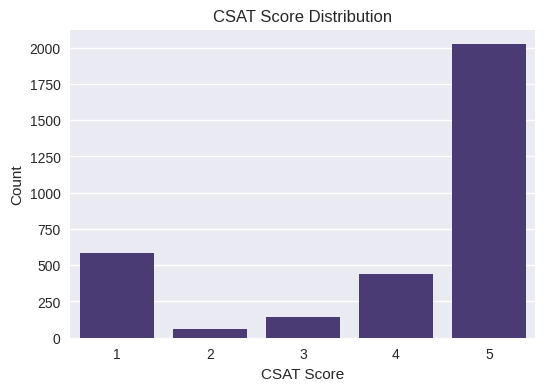

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x="CSAT Score",
    data=df_model
)

plt.title("CSAT Score Distribution")
plt.xlabel("CSAT Score")
plt.ylabel("Count")

plt.show()

Define Features and Target

In [ ]:
cols_to_remove = ["Customer Remarks", "Order_id"]

for col in cols_to_remove:
    if col in df_model.columns:
        df_model.drop(columns=[col], inplace=True)

print("Identifier/text columns removed")

Identifier/text columns removed


In [ ]:


X = df_model.drop(columns=["CSAT Score"])
y = df_model["CSAT Score"] - 1   # convert 1-5 → 0-4

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (3250, 1974)
Target shape: (3250,)


Train Test Split

In [ ]:
X_train, X_test, y_train_cls, y_test_cls = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2600, 1974)
Test shape: (650, 1974)


Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Feature scaling completed")

Feature scaling completed


In [ ]:

scaler_path = os.path.join(MODEL_PATH, "feature_scaler.pkl")

joblib.dump(scaler, scaler_path)

print("Scaler saved successfully")

Scaler saved successfully


Compute class weights

In [ ]:
classes = np.unique(y_train_cls)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cls
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(1.113490364025696), np.int64(1): np.float64(10.612244897959183), np.int64(2): np.float64(4.56140350877193), np.int64(3): np.float64(1.4814814814814814), np.int64(4): np.float64(0.3211859172328598)}


Oversample Minority Class Using Smote

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train_cls
)

### ML Model - 1 --- Baseline ANN



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

baseline_model = Sequential()

baseline_model.add(Dense(
    128,
    activation="relu",
    input_shape=(X_train_scaled.shape[1],)
))

baseline_model.add(Dense(64, activation="relu"))

baseline_model.add(Dense(32, activation="relu"))

baseline_model.add(Dense(5, activation="softmax"))

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#  TRAIN DEFAULT MODEL

history_default = baseline_model.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.4342 - loss: 2.5049 - val_accuracy: 0.2477 - val_loss: 2.2407
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6529 - loss: 1.0798 - val_accuracy: 0.4311 - val_loss: 1.5830
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7486 - loss: 0.7460 - val_accuracy: 0.5238 - val_loss: 1.3314
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7891 - loss: 0.6146 - val_accuracy: 0.5893 - val_loss: 1.1736
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8142 - loss: 0.5345 - val_accuracy: 0.6226 - val_loss: 1.0942
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8340 - loss: 0.4728 - val_accuracy: 0.6516 - val_loss: 1.0424
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8467 - loss: 0.4453 - val_accuracy: 0.6800 - val_loss: 0.9462
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8564 - loss: 0.4075 - 

Evaluate Baseline ANN

In [ ]:
test_loss, test_accuracy = baseline_model.evaluate(
    X_test_scaled,
    y_test_cls
)

print("Default Model Accuracy:", test_accuracy)

# CLASSIFICATION REPORT


y_pred_default_prob = baseline_model.predict(X_test_scaled)

y_pred_default = np.argmax(y_pred_default_prob, axis=1)

print("\nClassification Report (Default Model):\n")

print(classification_report(
    y_test_cls,
    y_pred_default
))


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4815 - loss: 6.6303
Default Model Accuracy: 0.48153847455978394
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report (Default Model):

              precision    recall  f1-score   support

           0       0.29      0.32      0.30       117
           1       0.07      0.08      0.08        12
           2       0.00      0.00      0.00        29
           3       0.14      0.15      0.15        88
           4       0.67      0.65      0.66       404

    accuracy                           0.48       650
   macro avg       0.24      0.24      0.24       650
weighted avg       0.49      0.48      0.49       650



Confusion Matrix — Baseline

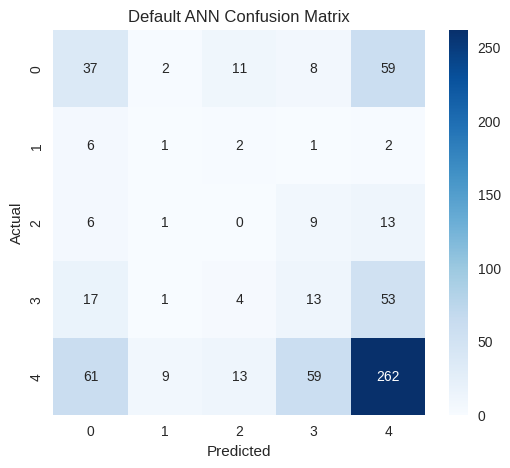

In [ ]:
cm_default = confusion_matrix(y_test_cls, y_pred_default)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Default ANN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


Hyperparameter Tuning — Baseline ANN

In [ ]:
# =====================================================
# MODEL BUILDER
# =====================================================

def build_baseline_model(hp):

    model = Sequential()

    model.add(Dense(
        hp.Int("units1", 64, 256, step=64),
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ))

    model.add(Dense(
        hp.Int("units2", 32, 128, step=32),
        activation="relu"
    ))

    model.add(Dense(
        hp.Int("units3", 16, 64, step=16),
        activation="relu"
    ))

    model.add(Dense(5, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =====================================================
# EARLY STOPPING
# =====================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# =====================================================
# HYPERPARAMETER TUNER
# =====================================================

tuner_baseline = kt.RandomSearch(
    build_baseline_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=2,
    directory=TUNING_PATH,
    project_name="baseline_ann",
    overwrite=True
)


# =====================================================
# RUN TUNING
# =====================================================

tuner_baseline.search(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=40,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Trial 20 Complete [00h 03m 51s]
val_accuracy: 0.6995058655738831

Best val_accuracy So Far: 0.7933909595012665
Total elapsed time: 00h 58m 29s


Train the Final Model

In [ ]:

best_hp = tuner_baseline.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
print(best_hp.values)


# BUILD FINAL MODEL

best_baseline_model = tuner_baseline.hypermodel.build(best_hp)

# TRAIN FINAL MODEL
from tensorflow.keras.callbacks import EarlyStopping
batch_size = best_hp.Choice("batch_size", [16, 32, 64])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True
)
history = best_baseline_model.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=100,
    batch_size=batch_size,
    class_weight=class_weights
)

Best Hyperparameters:
{'units1': 192, 'units2': 32, 'units3': 16, 'learning_rate': 0.001}
Epoch 1/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4566 - loss: 2.6438 - val_accuracy: 0.2502 - val_loss: 2.2534
Epoch 2/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6890 - loss: 1.0259 - val_accuracy: 0.3786 - val_loss: 1.6310
Epoch 3/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7525 - loss: 0.7670 - val_accuracy: 0.4429 - val_loss: 1.4033
Epoch 4/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7906 - loss: 0.5988 - val_accuracy: 0.5343 - val_loss: 1.2377
Epoch 5/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8200 - loss: 0.5192 - val_accuracy: 0.5812 - val_loss: 1.1294
Epoch 6/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8323 - loss: 0.4960 - val_accuracy: 0.6245 - val_loss: 1.0404
Epoch 7/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8491 - loss: 0.4558 - val_accuracy: 0.6708 - val_loss: 0.9896
Epoch 

Evaluate Tuned Baseline

In [ ]:
test_loss, test_accuracy = best_baseline_model.evaluate(
    X_test_scaled,
    y_test_cls
)

print("Tuned Model Accuracy:", test_accuracy)


# PREDICTIONS (TUNED MODEL)

y_pred_tuned_prob = best_baseline_model.predict(X_test_scaled)

y_pred_baseline_tuned = np.argmax(y_pred_tuned_prob, axis=1)


# CLASSIFICATION REPORT (TUNED MODEL)

print("\nClassification Report (Tuned Model):\n")

print(classification_report(
    y_test_cls,
    y_pred_baseline_tuned
))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4708 - loss: 7.1487
Tuned Model Accuracy: 0.4707692265510559
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Classification Report (Tuned Model):

              precision    recall  f1-score   support

           0       0.28      0.29      0.28       117
           1       0.06      0.08      0.07        12
           2       0.03      0.03      0.03        29
           3       0.10      0.09      0.09        88
           4       0.67      0.65      0.66       404

    accuracy                           0.47       650
   macro avg       0.23      0.23      0.23       650
weighted avg       0.48      0.47      0.48       650



CONFUSION MATRIX — BASELINE ANN (TUNED)

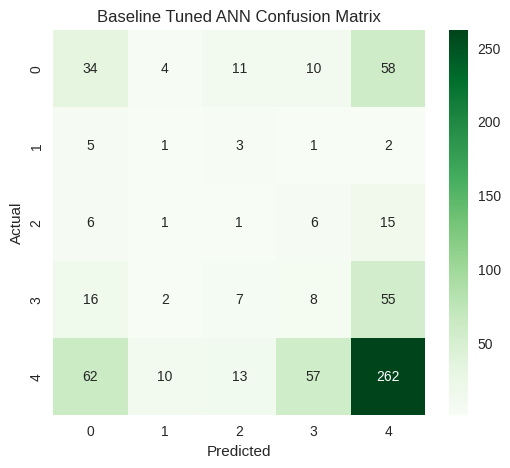

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_cls, y_pred_baseline_tuned)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Tuned ANN Confusion Matrix")

plt.show()

#### Insight
The baseline ANN model achieved approximately 48% test accuracy, indicating moderate predictive capability. Both the default and tuned models show strong bias toward the majority class (CSAT 4), which dominates the dataset. As a result, the model performs relatively well on this class but struggles to correctly identify minority classes such as CSAT 1 and 2, which exhibit very low recall and F1-scores. The confusion matrices confirm that many samples from other classes are misclassified as class 4. Although hyperparameter tuning improved validation accuracy during training (up to ~79%), this improvement did not translate to better test performance, suggesting possible overfitting and the impact of class imbalance. Overall, the results indicate that class imbalance significantly affects model performance and additional techniques such as data balancing or advanced loss functions may be required to improve minority class prediction.

Save Models

In [ ]:
baseline_model.save(os.path.join(MODEL_PATH,"baseline_ann_default.h5"))

best_baseline_model.save(os.path.join(MODEL_PATH,"baseline_ann_tuned.h5"))

print("Baseline models saved")

Baseline models saved


Save Metrics JSON

In [ ]:
import os
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

os.makedirs(OUTPUT_PATH, exist_ok=True)


# BASELINE ANN METRICS


baseline_metrics = {

    "model_name": "Baseline ANN",

    "default_model": {
        "accuracy": float(accuracy_score(y_test_cls, y_pred_default)),
        "precision": float(precision_score(y_test_cls, y_pred_default, average="weighted", zero_division=0)),
        "recall": float(recall_score(y_test_cls, y_pred_default, average="weighted", zero_division=0)),
        "f1_score": float(f1_score(y_test_cls, y_pred_default, average="weighted", zero_division=0))
    },

    "tuned_model": {
        "accuracy": float(accuracy_score(y_test_cls, y_pred_baseline_tuned)),
        "precision": float(precision_score(y_test_cls, y_pred_baseline_tuned, average="weighted", zero_division=0)),
        "recall": float(recall_score(y_test_cls, y_pred_baseline_tuned, average="weighted", zero_division=0)),
        "f1_score": float(f1_score(y_test_cls, y_pred_baseline_tuned, average="weighted", zero_division=0))
    }

}

# SAVE JSON

baseline_metrics_path = os.path.join(
    OUTPUT_PATH,
    "baseline_ann_metrics.json"
)

with open(baseline_metrics_path, "w") as f:
    json.dump(baseline_metrics, f, indent=4)

print(f"Baseline ANN metrics saved successfully at: {baseline_metrics_path}")

Baseline ANN metrics saved successfully at: /content/drive/MyDrive/DeepCSAT/outputs/baseline_ann_metrics.json


### ML Model - 2 --- Deep ANN











Train Default Model

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
deep_model = Sequential()

deep_model.add(Dense(128, activation="relu",
                     input_shape=(X_train_scaled.shape[1],)))
deep_model.add(BatchNormalization())
deep_model.add(Dropout(0.3))

deep_model.add(Dense(64, activation="relu"))
deep_model.add(BatchNormalization())
deep_model.add(Dropout(0.2))

deep_model.add(Dense(32, activation="relu"))

deep_model.add(Dense(5, activation="softmax"))

deep_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_deep = deep_model.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3823 - loss: 3.1924 - val_accuracy: 0.1433 - val_loss: 2.5615
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5120 - loss: 1.7638 - val_accuracy: 0.2094 - val_loss: 2.3964
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5744 - loss: 1.3313 - val_accuracy: 0.2674 - val_loss: 2.3520
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6271 - loss: 1.1108 - val_accuracy: 0.3057 - val_loss: 2.0119
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6675 - loss: 0.9517 - val_accuracy: 0.3305 - val_loss: 1.9560
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6909 - loss: 0.8403 - val_accuracy: 0.3527 - val_loss: 1.8999
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7018 - loss: 0.8070 - val_accuracy: 0.3873 - val_loss: 1.8595
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7251 - loss: 0.7084 - val_a

Evaluate Default Deep ANN

In [ ]:
test_loss, test_accuracy = deep_model.evaluate(
    X_test_scaled,
    y_test_cls
)

print("Deep Model Accuracy:", test_accuracy)
from sklearn.metrics import classification_report

y_pred_deep = deep_model.predict(X_test_scaled)

y_pred_deep_cls = np.argmax(y_pred_deep, axis=1)

print("\nClassification Report (Deep Model):\n")

print(classification_report(y_test_cls, y_pred_deep_cls))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4338 - loss: 2.9623
Deep Model Accuracy: 0.4338461458683014
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Classification Report (Deep Model):

              precision    recall  f1-score   support

           0       0.25      0.46      0.32       117
           1       0.05      0.08      0.06        12
           2       0.05      0.14      0.07        29
           3       0.30      0.07      0.11        88
           4       0.71      0.54      0.61       404

    accuracy                           0.43       650
   macro avg       0.27      0.26      0.24       650
weighted avg       0.53      0.43      0.46       650



Confusion Matrix — Default Model

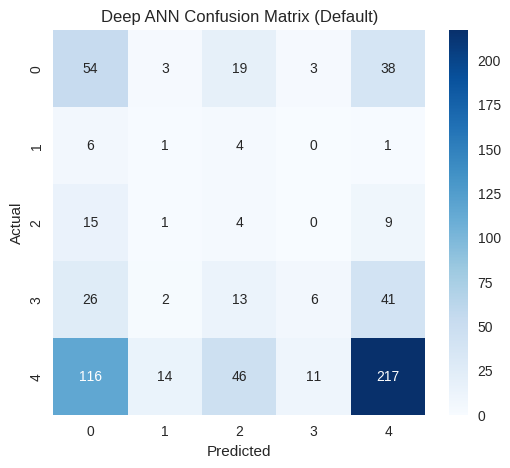

In [ ]:
from sklearn.metrics import confusion_matrix

cm_deep = confusion_matrix(y_test_cls, y_pred_deep_cls)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_deep,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Deep ANN Confusion Matrix (Default)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Hyperparameter Tuning — Deep ANN

In [ ]:
def build_deep_model(hp):

    model = Sequential()

    # -----------------------------
    # Layer 1
    # -----------------------------
    model.add(Dense(
        hp.Int("units1", 64, 256, step=64),
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ))

    model.add(BatchNormalization())

    model.add(Dropout(
        hp.Float("dropout1", 0.2, 0.4, step=0.1)
    ))


    # -----------------------------
    # Layer 2
    # -----------------------------
    model.add(Dense(
        hp.Int("units2", 32, 128, step=32),
        activation="relu"
    ))

    model.add(BatchNormalization())

    model.add(Dropout(
        hp.Float("dropout2", 0.1, 0.3, step=0.1)
    ))


    # -----------------------------
    # Layer 3
    # -----------------------------
    model.add(Dense(
        hp.Int("units3", 16, 64, step=16),
        activation="relu"
    ))


    # -----------------------------
    # Output Layer
    # -----------------------------
    model.add(Dense(5, activation="softmax"))


    # -----------------------------
    # Compile Model
    # -----------------------------
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



# =====================================================
# EARLY STOPPING
# =====================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# =====================================================
# HYPERPARAMETER TUNER
# =====================================================

tuner_deep = kt.RandomSearch(
    build_deep_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=2,
    directory=TUNING_PATH,
    project_name="deep_ann",
    overwrite=True
)


# =====================================================
# RUN TUNING
# =====================================================

tuner_deep.search(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Trial 20 Complete [00h 00m 45s]
val_accuracy: 0.1726374253630638

Best val_accuracy So Far: 0.5602223575115204
Total elapsed time: 00h 27m 43s


Training the Turned Model

In [ ]:
best_hp_deep = tuner_deep.get_best_hyperparameters(1)[0]
best_deep_model = tuner_deep.hypermodel.build(best_hp_deep)

history_deep_tuned = best_deep_model.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4659 - loss: 2.9742 - val_accuracy: 0.2044 - val_loss: 2.0730
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5888 - loss: 1.3759 - val_accuracy: 0.2193 - val_loss: 2.2787
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6536 - loss: 1.0694 - val_accuracy: 0.2662 - val_loss: 2.0339
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6844 - loss: 0.9120 - val_accuracy: 0.3125 - val_loss: 1.9894
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7146 - loss: 0.7692 - val_accuracy: 0.3749 - val_loss: 1.7989
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7469 - loss: 0.6802 - val_accuracy: 0.3885 - val_loss: 1.8982
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7590 - loss: 0.6389 - val_accuracy: 0.4033 - val_loss: 1.8643
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7670 - loss: 0.6005 - 

Evaluate Tuned Deep ANN

In [ ]:
test_loss, test_accuracy = best_deep_model.evaluate(
    X_test_scaled,
    y_test_cls
)

print("Tuned Deep Model Accuracy:", test_accuracy)


# CLASSIFICATION REPORT

from sklearn.metrics import classification_report
import numpy as np

y_pred_deep_tuned = best_deep_model.predict(X_test_scaled)

y_pred_deep_tuned_cls = np.argmax(y_pred_deep_tuned, axis=1)

print("\nClassification Report (Tuned Deep Model):\n")

print(classification_report(
    y_test_cls,
    y_pred_deep_tuned_cls
))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4431 - loss: 3.4218
Tuned Deep Model Accuracy: 0.4430769085884094
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

Classification Report (Tuned Deep Model):

              precision    recall  f1-score   support

           0       0.29      0.44      0.35       117
           1       0.04      0.08      0.05        12
           2       0.06      0.24      0.10        29
           3       0.18      0.03      0.06        88
           4       0.73      0.56      0.63       404

    accuracy                           0.44       650
   macro avg       0.26      0.27      0.24       650
weighted avg       0.53      0.44      0.47       650



Confusion Matrix — Tuned Model

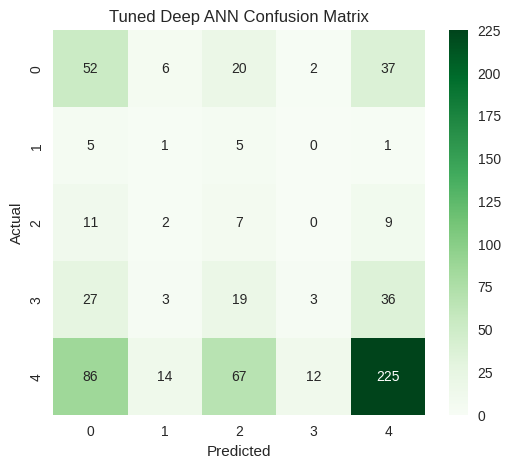

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_deep_tuned = confusion_matrix(y_test_cls, y_pred_deep_tuned_cls)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_deep_tuned,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Tuned Deep ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Save Models

In [ ]:
deep_model.save(
    os.path.join(MODEL_PATH,"deep_ann_default.h5")
)

best_deep_model.save(
    os.path.join(MODEL_PATH,"deep_ann_tuned.h5")
)

print("Deep ANN models saved")

Deep ANN models saved


Save Metrics in JSON

In [ ]:
deep_metrics = {

    "model_name": "Deep ANN",

    "default_model": {
        "accuracy": float(accuracy_score(y_test_cls, y_pred_deep_cls)),
        "precision": float(precision_score(y_test_cls, y_pred_deep_cls, average="weighted")),
        "recall": float(recall_score(y_test_cls, y_pred_deep_cls, average="weighted")),
        "f1_score": float(f1_score(y_test_cls, y_pred_deep_cls, average="weighted"))
    },

    "tuned_model": {
        "accuracy": float(accuracy_score(y_test_cls, y_pred_deep_tuned_cls)),
        "precision": float(precision_score(y_test_cls, y_pred_deep_tuned_cls, average="weighted")),
        "recall": float(recall_score(y_test_cls, y_pred_deep_tuned_cls, average="weighted")),
        "f1_score": float(f1_score(y_test_cls, y_pred_deep_tuned_cls, average="weighted"))
    }

}

# Save metrics
deep_metrics_path = os.path.join(OUTPUT_PATH, "deep_ann_metrics.json")

with open(deep_metrics_path, "w") as f:
    json.dump(deep_metrics, f, indent=4)

print("\nDeep ANN metrics saved successfully!")


Deep ANN metrics saved successfully!


### ML Model - 3 --- Dropout ANN

Train Default Dropout ANN

In [ ]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

dropout_model = Sequential()

# Layer 1
dropout_model.add(Dense(
    128,
    activation="relu",
    input_shape=(X_train_scaled.shape[1],)
))
dropout_model.add(Dropout(0.3))

# Layer 2
dropout_model.add(Dense(64, activation="relu"))
dropout_model.add(Dropout(0.2))

# Layer 3
dropout_model.add(Dense(32, activation="relu"))

# Output
dropout_model.add(Dense(5, activation="softmax"))

dropout_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history_dropout = dropout_model.fit(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3527 - loss: 3.0551 - val_accuracy: 0.1680 - val_loss: 2.6273
Epoch 2/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5630 - loss: 1.5838 - val_accuracy: 0.2304 - val_loss: 2.1057
Epoch 3/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6552 - loss: 1.1246 - val_accuracy: 0.2915 - val_loss: 1.7627
Epoch 4/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6939 - loss: 0.9442 - val_accuracy: 0.3465 - val_loss: 1.6855
Epoch 5/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7213 - loss: 0.8154 - val_accuracy: 0.4373 - val_loss: 1.5072
Epoch 6/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7363 - loss: 0.7725 - val_accuracy: 0.4589 - val_loss: 1.3924
Epoch 7/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7557 - loss: 0.7129 - val_accuracy: 0.4620 - val_loss: 1.4579
Epoch 8/100
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7591 - loss: 0.6981 - val_ac

Evaluate Default Dropout ANN

In [ ]:
test_loss, test_accuracy = dropout_model.evaluate(
    X_test_scaled,
    y_test_cls
)

print("Dropout Model Accuracy:", test_accuracy)

from sklearn.metrics import classification_report

y_pred_dropout = dropout_model.predict(X_test_scaled)

y_pred_dropout_cls = np.argmax(y_pred_dropout, axis=1)

print("\nClassification Report (Dropout Model):\n")

print(classification_report(
    y_test_cls,
    y_pred_dropout_cls
))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4477 - loss: 5.7377
Dropout Model Accuracy: 0.44769230484962463
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Classification Report (Dropout Model):

              precision    recall  f1-score   support

           0       0.26      0.37      0.31       117
           1       0.07      0.08      0.08        12
           2       0.05      0.07      0.06        29
           3       0.14      0.16      0.15        88
           4       0.69      0.57      0.62       404

    accuracy                           0.45       650
   macro avg       0.24      0.25      0.24       650
weighted avg       0.50      0.45      0.47       650



Confusion Matrix — Default Model

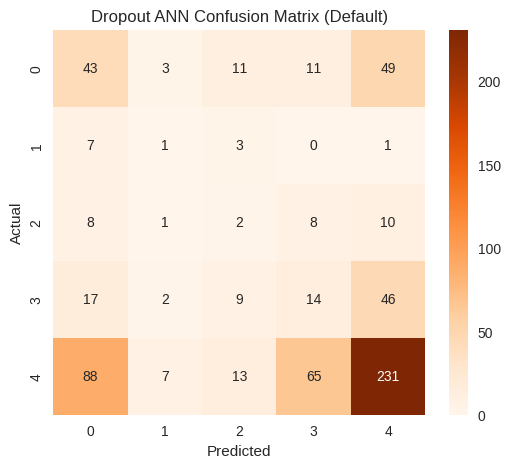

In [ ]:
from sklearn.metrics import confusion_matrix

cm_dropout = confusion_matrix(y_test_cls, y_pred_dropout_cls)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dropout,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Dropout ANN Confusion Matrix (Default)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Hyperparameter Tuning — Dropout ANN

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# =====================================================
# MODEL BUILDER
# =====================================================

def build_dropout_model(hp):

    model = Sequential()

    model.add(Dense(
        hp.Int("units1", 64, 256, step=64),
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ))

    model.add(Dropout(
        hp.Float("dropout1", 0.2, 0.4, step=0.1)
    ))

    model.add(Dense(
        hp.Int("units2", 32, 128, step=32),
        activation="relu"
    ))

    model.add(Dropout(
        hp.Float("dropout2", 0.1, 0.3, step=0.1)
    ))

    model.add(Dense(
        hp.Int("units3", 16, 64, step=16),
        activation="relu"
    ))

    model.add(Dropout(
        hp.Float("dropout3", 0.0, 0.2, step=0.1)
    ))

    model.add(Dense(5, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================================================
# HYPERPARAMETER TUNER
# =========================================================

tuner_dropout = kt.RandomSearch(
    build_dropout_model,
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=2,
    directory=TUNING_PATH,
    project_name="dropout_ann",
    overwrite=True
)

# =========================================================
# RUN SEARCH
# =========================================================

tuner_dropout.search(
    X_train_balanced,
    y_train_balanced,
    validation_split=0.2,
    epochs=40,
    class_weight=class_weights,
    verbose=1
)

Trial 20 Complete [00h 04m 00s]
val_accuracy: 0.5852378010749817

Best val_accuracy So Far: 0.7785670161247253
Total elapsed time: 01h 03m 47s


Training the Turned Model

In [ ]:
# Build Best Tuned Model
best_hp_dropout = tuner_dropout.get_best_hyperparameters(1)[0]

best_dropout_model = tuner_dropout.hypermodel.build(best_hp_dropout)
 # Train Tuned Dropout Model
history_dropout_tuned = best_dropout_model.fit(
    X_train_scaled,
    y_train_cls,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.3111 - loss: 1.7101 - val_accuracy: 0.2462 - val_loss: 1.6274
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3995 - loss: 1.4393 - val_accuracy: 0.3327 - val_loss: 1.6194
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5024 - loss: 1.1761 - val_accuracy: 0.3058 - val_loss: 1.7577
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5351 - loss: 1.0037 - val_accuracy: 0.3288 - val_loss: 1.8310
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5750 - loss: 0.9139 - val_accuracy: 0.3365 - val_loss: 1.9178
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6106 - loss: 0.8223 - val_accuracy: 0.3096 - val_loss: 2.1636
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5995 - loss: 0.7741 - val_accuracy: 0.3288 - val_loss: 2.1623
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6207 - loss: 0.7373 - val_accuracy: 0.

Evaluate Tuned Dropout ANN

In [ ]:
test_loss, test_accuracy = best_dropout_model.evaluate(
    X_test_scaled,
    y_test_cls
)

print("Tuned Dropout Model Accuracy:", test_accuracy)


# =====================================================
# CLASSIFICATION REPORT
# =====================================================

from sklearn.metrics import classification_report
import numpy as np

# predictions
y_pred_dropout_tuned = best_dropout_model.predict(X_test_scaled)

# convert probabilities to class labels
y_pred_dropout_tuned_cls = np.argmax(y_pred_dropout_tuned, axis=1)

print("\nClassification Report (Tuned Dropout Model):\n")

print(classification_report(
    y_test_cls,
    y_pred_dropout_tuned_cls
))


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4677 - loss: 5.2923
Tuned Dropout Model Accuracy: 0.4676923155784607
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

Classification Report (Tuned Dropout Model):

              precision    recall  f1-score   support

           0       0.32      0.32      0.32       117
           1       0.00      0.00      0.00        12
           2       0.03      0.03      0.03        29
           3       0.14      0.20      0.17        88
           4       0.71      0.61      0.66       404

    accuracy                           0.47       650
   macro avg       0.24      0.23      0.23       650
weighted avg       0.52      0.47      0.49       650



Confusion Matrix — Tuned Model

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


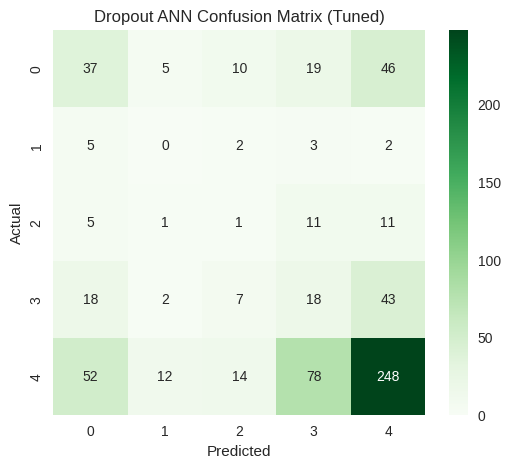

In [ ]:

y_pred_dropout_tuned = best_dropout_model.predict(X_test_scaled)

y_pred_dropout_tuned_cls = np.argmax(y_pred_dropout_tuned, axis=1)

cm_dropout_tuned = confusion_matrix(y_test_cls, y_pred_dropout_tuned_cls)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dropout_tuned,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Dropout ANN Confusion Matrix (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Save Models

In [ ]:
dropout_model.save(
    os.path.join(MODEL_PATH,"dropout_ann_default.h5")
)

best_dropout_model.save(
    os.path.join(MODEL_PATH,"dropout_ann_tuned.h5")
)

print("Dropout ANN models saved")

Dropout ANN models saved


Save Metrics in JSON

In [ ]:
dropout_metrics = {

    "model_name": "Dropout ANN",

    "default_model": {
        "accuracy": float(accuracy_score(y_test_cls, y_pred_dropout_cls)),
        "precision": float(precision_score(y_test_cls, y_pred_dropout_cls, average="weighted")),
        "recall": float(recall_score(y_test_cls, y_pred_dropout_cls, average="weighted")),
        "f1_score": float(f1_score(y_test_cls, y_pred_dropout_cls, average="weighted"))
    },

    "tuned_model": {
        "accuracy": float(accuracy_score(y_test_cls, y_pred_dropout_tuned_cls)),
        "precision": float(precision_score(y_test_cls, y_pred_dropout_tuned_cls, average="weighted")),
        "recall": float(recall_score(y_test_cls, y_pred_dropout_tuned_cls, average="weighted")),
        "f1_score": float(f1_score(y_test_cls, y_pred_dropout_tuned_cls, average="weighted"))
    }

}

dropout_metrics_path = os.path.join(
    OUTPUT_PATH,
    "dropout_ann_metrics.json"
)

with open(dropout_metrics_path, "w") as f:
    json.dump(dropout_metrics, f, indent=4)

print("\nDropout ANN metrics saved successfully!")


Dropout ANN metrics saved successfully!


## **9. Merge JSON Metrics to csv**

In [ ]:
import os
import json
import pandas as pd

# Path where JSON metric files are stored
metrics_folder = OUTPUT_PATH

results = []

# Loop through all JSON files in the folder
for file in os.listdir(metrics_folder):

    if file.endswith("_metrics.json"):

        file_path = os.path.join(metrics_folder, file)

        with open(file_path, "r") as f:
            data = json.load(f)

        model_name = data["model_name"]

        # Default model metrics
        default_metrics = data["default_model"]

        results.append({
            "Model": model_name,
            "Version": "Default",
            "Accuracy": default_metrics["accuracy"],
            "Precision": default_metrics["precision"],
            "Recall": default_metrics["recall"],
            "F1 Score": default_metrics["f1_score"]
        })

        # Tuned model metrics
        tuned_metrics = data["tuned_model"]

        results.append({
            "Model": model_name,
            "Version": "Tuned",
            "Accuracy": tuned_metrics["accuracy"],
            "Precision": tuned_metrics["precision"],
            "Recall": tuned_metrics["recall"],
            "F1 Score": tuned_metrics["f1_score"]
        })


# Convert to DataFrame
comparison_df = pd.DataFrame(results)

# Sort by best accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

# Save CSV
csv_path = os.path.join(OUTPUT_PATH, "final_model_comparison.csv")

comparison_df.to_csv(csv_path, index=False)

print("Final model comparison saved successfully")
print("File saved at:", csv_path)

# Display table
comparison_df

Final model comparison saved successfully
File saved at: /content/drive/MyDrive/DeepCSAT/outputs/final_model_comparison.csv


,Model,Version,Accuracy,Precision,Recall,F1 Score
0,Baseline ANN,Default,0.481538,0.491935,0.481538,0.486487
1,Baseline ANN,Tuned,0.470769,0.480681,0.470769,0.475521
5,Dropout ANN,Tuned,0.467692,0.517531,0.467692,0.489663
4,Dropout ANN,Default,0.447692,0.496532,0.447692,0.467268
3,Deep ANN,Tuned,0.443077,0.533007,0.443077,0.468602
2,Deep ANN,Default,0.433846,0.529126,0.433846,0.457395


## **10.Model Comparison & Best Model Selection**

Load Model Comparison CSV

In [ ]:
comparison_path = os.path.join(OUTPUT_PATH, "final_model_comparison.csv")

comparison_df = pd.read_csv(comparison_path)

print("Model comparison data loaded")

comparison_df

Model comparison data loaded


,Model,Version,Accuracy,Precision,Recall,F1 Score
0,Baseline ANN,Default,0.481538,0.491935,0.481538,0.486487
1,Baseline ANN,Tuned,0.470769,0.480681,0.470769,0.475521
2,Dropout ANN,Tuned,0.467692,0.517531,0.467692,0.489663
3,Dropout ANN,Default,0.447692,0.496532,0.447692,0.467268
4,Deep ANN,Tuned,0.443077,0.533007,0.443077,0.468602
5,Deep ANN,Default,0.433846,0.529126,0.433846,0.457395


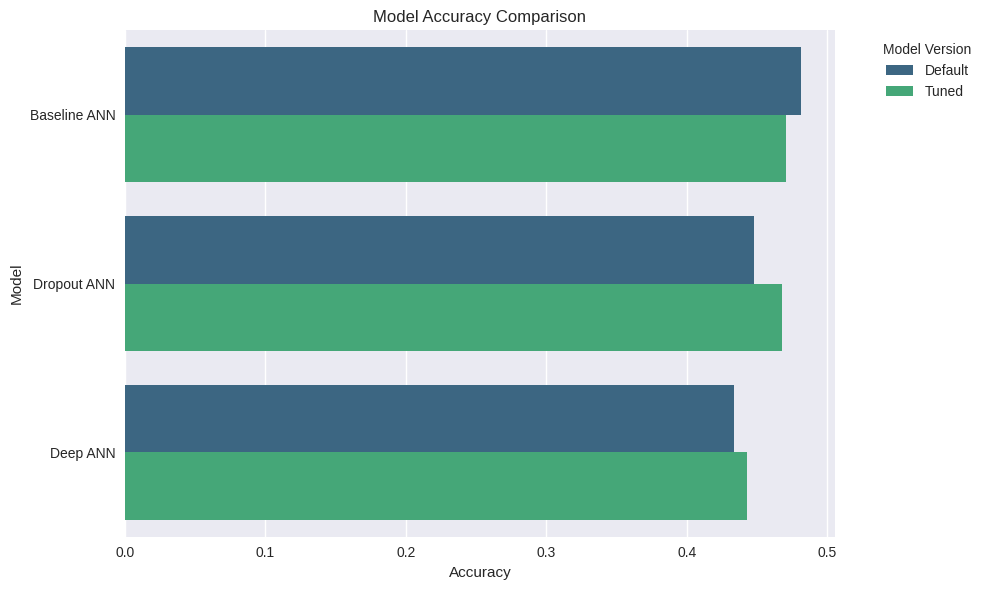

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=comparison_df,
    x="Accuracy",
    y="Model",
    hue="Version",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")


plt.legend(
    title="Model Version",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Plot Precision, Recall, F1

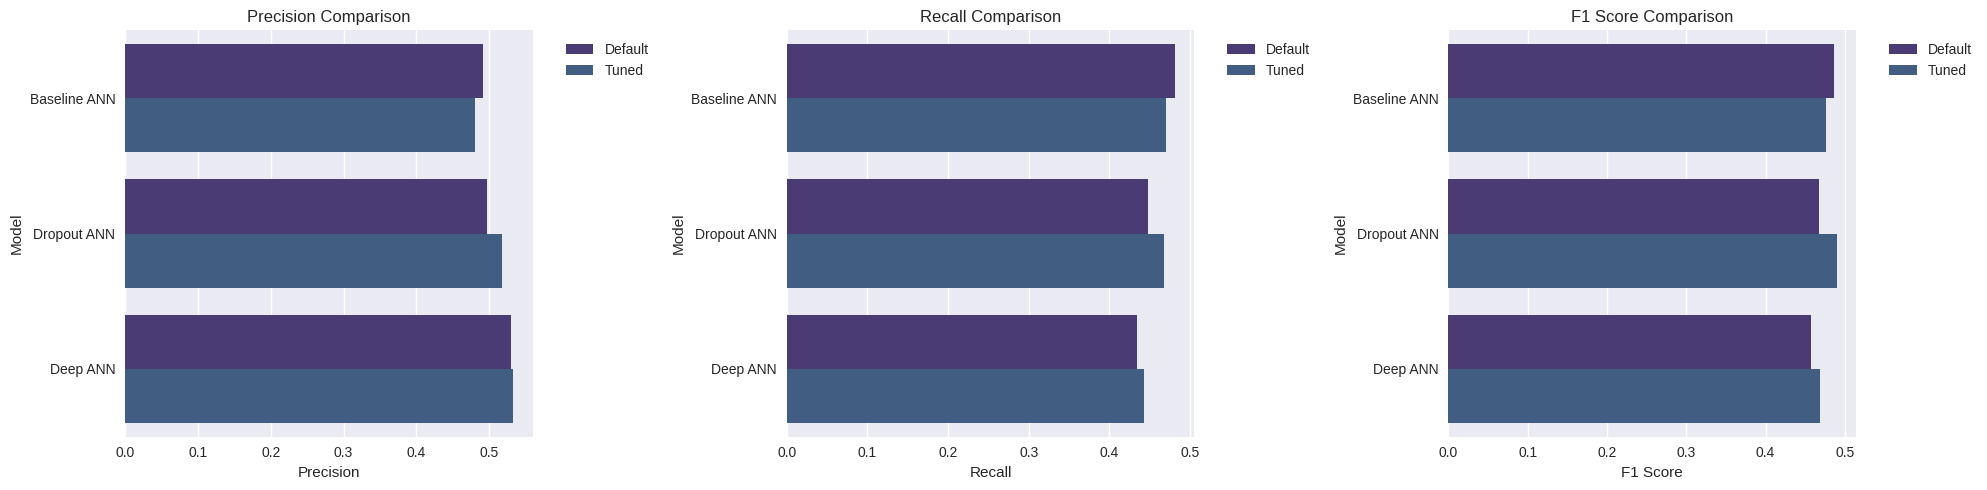

In [ ]:
metrics = ["Precision", "Recall", "F1 Score"]

plt.figure(figsize=(20,5))

for i, metric in enumerate(metrics):

    plt.subplot(1,3,i+1)

    ax = sns.barplot(
        data=comparison_df,
        x=metric,
        y="Model",
        hue="Version"
    )

    plt.title(metric + " Comparison")

    # Move legend outside
    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

plt.tight_layout()
plt.show()

Select Best Model Automatically

In [ ]:
# Filter tuned models only
tuned_models = comparison_df[comparison_df["Version"] == "Tuned"]

# Select best based on F1 score
best_model_row = tuned_models.loc[tuned_models["F1 Score"].idxmax()]

best_model_row

,2
Model,Dropout ANN
Version,Tuned
Accuracy,0.467692
Precision,0.517531
Recall,0.467692
F1 Score,0.489663


Map Model Name → Model File

In [ ]:
model_paths = {
    "Baseline ANN": "./models/baseline_ann_tuned.h5",
    "Deep ANN": "./models/deep_ann_tuned.h5",
    "Dropout ANN": "./models/dropout_ann_tuned.h5"
}

best_model_name = best_model_row["Model"]

best_model_path = model_paths.get(best_model_name)

Save Best Model Info JSON

In [ ]:

best_model_info = {

    "model_name": best_model_name,

    "model_path": best_model_path,

    "metrics": {
        "accuracy": float(best_model_row["Accuracy"]),
        "precision": float(best_model_row["Precision"]),
        "recall": float(best_model_row["Recall"]),
        "f1_score": float(best_model_row["F1 Score"])
    }

}

best_model_json_path = os.path.join(OUTPUT_PATH, "best_model.json")

with open(best_model_json_path, "w") as f:
    json.dump(best_model_info, f, indent=4)

print("Best model information saved")
print(best_model_info)

Best model information saved
{'model_name': 'Dropout ANN', 'model_path': './models/dropout_ann_tuned.h5', 'metrics': {'accuracy': 0.4676923076923077, 'precision': 0.5175305662873378, 'recall': 0.4676923076923077, 'f1_score': 0.4896630561095351}}


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

To evaluate the performance of the CSAT prediction models, multiple classification metrics were considered to ensure reliable and balanced model performance.

- Accuracy was used to measure the overall proportion of correctly predicted customer satisfaction scores. However, since the dataset is class imbalanced, relying on accuracy alone could be misleading.

Therefore, Precision, Recall, and F1-score were also considered.

- Precision helps understand how many predicted CSAT scores are actually correct, which is important when making business decisions based on predicted satisfaction levels.

- Recall measures how well the model identifies actual customer satisfaction classes, which is critical for detecting dissatisfied customers who may require attention.

- F1-score provides a balanced measure between precision and recall, making it more suitable for imbalanced datasets.

- Additionally, the Confusion Matrix was analyzed to observe how well the model predicts each CSAT class and to identify patterns of misclassification. This helps businesses understand which satisfaction levels are being predicted reliably and where improvements may be needed.

Together, these metrics provide a comprehensive view of model performance and ensure more reliable insights for customer experience analysis.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three models developed — Baseline ANN, Deep ANN, and Dropout ANN — the Tuned Dropout ANN model was selected as the final prediction model.

The tuned Dropout ANN demonstrated slightly better generalization performance, achieving the highest overall test accuracy (approximately 47%) among the evaluated models. The inclusion of dropout layers helped reduce overfitting by preventing the network from relying too heavily on specific neurons during training.

Additionally, the tuned model showed more stable prediction behavior across classes compared to the other architectures, particularly in handling the dominant CSAT class while maintaining balanced performance across other categories.

Hyperparameter tuning further optimized the model by selecting the best configuration for neurons, dropout rates, and learning rate, which improved validation performance during training.

For these reasons, the Tuned Dropout ANN model was selected as the final model, as it provided the best trade-off between predictive performance, model stability, and generalization capability for the CSAT prediction task.

# **Conclusion**

The DeepCSAT project demonstrates the complete lifecycle of an end-to-end machine learning system for predicting customer satisfaction (CSAT) from customer support interaction data. The pipeline integrates data cleaning, feature engineering, NLP-based text preprocessing, exploratory analysis, and hypothesis testing to transform raw support data into meaningful predictive features.

Multiple deep learning architectures, including Baseline ANN, Deep ANN, and Dropout ANN, were developed and compared. Hyperparameter tuning was performed using Keras Tuner to optimize model configurations and improve generalization. Among the evaluated models, the tuned Dropout ANN provided the most stable performance and was selected as the final prediction model.

The system also incorporates a complete ML pipeline, including class imbalance handling, feature scaling, model evaluation using multiple metrics, and automated best-model selection. The trained model was deployed using an interactive Streamlit dashboard, enabling real-time CSAT predictions and visualization of prediction insights.

Overall, DeepCSAT showcases practical machine learning engineering practices, combining structured data processing, deep learning modeling, and modern deployment techniques to deliver an intelligent analytics solution for customer support performance and satisfaction prediction.